# 环境验收 Notebook｜吕基恒

**用途**：确认 VS Code 里的 Jupyter 内核是 conda 的 `bioinfo` 环境。

**跑法**：右上角「内核」选 `Python (bioinfo)` → 逐个单元格按 `Shift+Enter`。

**注意**：如果右上角没有 `Python (bioinfo)` 这个选项，说明安装清单第 3 节的 `ipykernel install` 那步没做，回去补。

In [1]:
# 第 1 格：内核是不是 bioinfo
import sys

print("解释器:", sys.executable)

if "bioinfo" in sys.executable:
    print("\n[OK] 内核正确 = bioinfo")
else:
    print("\n[FAIL] 内核不是 bioinfo，请重新选择内核")

解释器: d:\miniconda3\envs\bioinfo\python.exe

[OK] 内核正确 = bioinfo


In [2]:
# 第 2 格：四个核心包能不能 import
import numpy as np
import pandas as pd
import matplotlib
import Bio

print("numpy      ", np.__version__)
print("pandas     ", pd.__version__)
print("matplotlib ", matplotlib.__version__)
print("biopython  ", Bio.__version__)

numpy       2.5.3
pandas      3.0.6
matplotlib  3.11.2
biopython   1.88


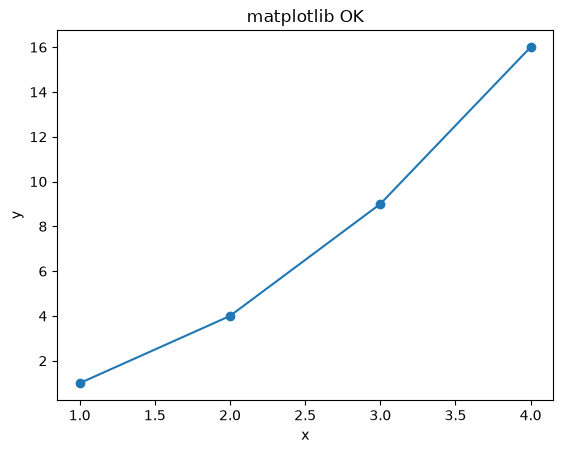

In [3]:
# 第 3 格：验证「图能画出来」——notebook 里图应该内联显示在单元格下方
import matplotlib.pyplot as plt

plt.plot([1, 2, 3, 4], [1, 4, 9, 16], marker="o")
plt.title("matplotlib OK")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [4]:
# 第 4 格：第一次读 FASTA（Mini Project 01 的起点，现在只确认不报错）
import tempfile
from pathlib import Path

from Bio import SeqIO
from Bio.SeqUtils import molecular_weight

# 造一条小序列来测，不依赖网络
test_fasta = Path(tempfile.gettempdir()) / "m1_test.fasta"
test_fasta.write_text(">test_protein\nMKTAYIAKQRQISFVKSHFSRQ\n", encoding="utf-8")

record = SeqIO.read(test_fasta, "fasta")
seq = record.seq

print("序列 ID :", record.id)
print("序列    :", seq)
print("长度    :", len(seq), "aa")
print("分子量  :", round(molecular_weight(seq, seq_type="protein"), 1), "Da")

序列 ID : test_protein
序列    : MKTAYIAKQRQISFVKSHFSRQ
长度    : 22 aa
分子量  : 2655.1 Da


In [5]:
# 第 5 格：第一次用 pandas 读 CSV（10/14 正式学，现在只确认能跑）
import io

csv_text = """sample,length,kd
P001,120,3.4
P002,95,7.1
P003,310,1.2
"""

df = pd.read_csv(io.StringIO(csv_text))
print(df)
print()
print("平均长度:", df["length"].mean())

  sample  length   kd
0   P001     120  3.4
1   P002      95  7.1
2   P003     310  1.2

平均长度: 175.0


## 验收判定

| 单元格 | 合格标准 |
|---|---|
| 第 1 格 | 打印 `[OK] 内核正确 = bioinfo` |
| 第 2 格 | 四个版本号都有输出 |
| 第 3 格 | 图**内联显示**在单元格下方（不是弹出新窗口） |
| 第 4 格 | 打印长度 22 aa，无报错 |
| 第 5 格 | 打印出三行表格 + 平均长度 |

全过 = 10/7 验收通过。任何一格红灯，把报错原文发给我。